In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.colors import ListedColormap
colors = ["royalblue", "skyblue", "lightgreen", "gold", "tomato", "maroon", "navy"]
cmap = ListedColormap(colors)

import pickle
import copy

import scanpy as sc
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.metrics import rand_score, confusion_matrix

from openTSNE import TSNE
from phate import PHATE
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
from umap import UMAP

import sys
sys.path.append('../code')
from align import *
from embed import *
from eval import *

# Load Data

In [2]:
import sys
sys.path.append('../../ne_spectrum_scRNAseq')
from data_utils import load_human

In [3]:
root_path = '../../ne_spectrum_scRNAseq/data/'
X, labels, d = load_human(root_path=root_path)
X.shape, labels.shape

((20272, 50), (20272,))

In [4]:
def convert(y):
    mapping = {'EB':0, 'Neuroectoderm':1, 'Neuroepithelium':2, 'Organoid-1M':3,
       'Organoid-2M':4, 'Organoid-4M':5, 'iPSCs':6}
    return [mapping[y[i]] for i in range(len(y))]
labels = convert(labels)
labels = np.array(labels)

In [5]:
np.unique(labels , return_counts = True)

(array([0, 1, 2, 3, 4, 5, 6]),
 array([ 855,  886,  443, 2416, 8056, 5673, 1943], dtype=int64))

In [9]:
n = X.shape[0]
n

20272

In [8]:
%%time
adata = sc.AnnData(X)
sc.pp.neighbors(adata, n_neighbors=15)

CPU times: total: 37.7 s
Wall time: 38 s


In [166]:
%%time
sc.tl.leiden(adata, resolution=0.025) 
clusters_4 = copy.deepcopy(adata.obs['leiden'])
rand_score(clusters_4, labels)

CPU times: total: 1.27 s
Wall time: 1.28 s


0.7047853255709524

In [103]:
%%time
sc.tl.leiden(adata, resolution=0.06) 
clusters_7 = copy.deepcopy(adata.obs['leiden'])
rand_score(clusters_7, labels)

CPU times: total: 1.12 s
Wall time: 1.13 s


0.7450851343148016

In [102]:
%%time
sc.tl.leiden(adata, resolution=0.5) 
clusters_20 = copy.deepcopy(adata.obs['leiden'])
rand_score(clusters_20, labels)

CPU times: total: 1.5 s
Wall time: 1.5 s


0.7850042928578223

In [10]:
%%time
sc.tl.leiden(adata, resolution=1) 
clusters_28 = copy.deepcopy(adata.obs['leiden'])
rand_score(clusters_28, labels)

<timed exec>:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.


CPU times: total: 2.11 s
Wall time: 2.12 s


0.7748677869485675

In [12]:
clusters_4 = np.array(clusters_4).astype(int)
clusters_7 = np.array(clusters_7).astype(int)
clusters_20 = np.array(clusters_20).astype(int)
clusters_28 = np.array(clusters_28).astype(int)

In [13]:
%%time
# approximate geodesic distances 
alignment_idxs = np.random.choice(n, 5000, replace = False)

D = shortest_path(
    adata.obsp["distances"],
    directed=False,
    indices= alignment_idxs # only compute from these sources
)


CPU times: total: 1min 16s
Wall time: 1min 17s


In [14]:
D = D[:,alignment_idxs]

In [15]:
np.sum(np.isinf(D))

0

In [29]:
# baseline embedding

with open('../results/brain/ce_isomap_embeddings.pkl', 'rb') as file:  
    temp = pickle.load(file)
ce_13 = temp[1]

In [168]:
clusters = clusters_4

l_isomap  = LandmarkIsomap(n_components = 2, n_landmarks = 300)
embeddings = np.zeros((n,2))
for i in np.unique(clusters):
    cluster_emb = l_isomap.fit_transform(adata[clusters == i])
    embeddings[clusters == i] = cluster_emb - np.mean(cluster_emb, axis = 0)

embedding_sampled = embeddings[alignment_idxs]
clusters_sampled = clusters[alignment_idxs]

distances = {} 

n_clusters = len(np.unique(clusters))
for i in range(n_clusters):
     for j in range(i+1, n_clusters):
            distances[i,j] = D[clusters_sampled == i, :][:,clusters_sampled == j]
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1)

In [169]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1.45)
ce_4 = out.align_embedding(m = 50 )
ce_4 =  out.embed_points(embeddings,clusters)

In [105]:
clusters = clusters_7

l_isomap  = LandmarkIsomap(n_components = 2, n_landmarks = 300)
embeddings = np.zeros((n,2))
for i in np.unique(clusters):
    cluster_emb = l_isomap.fit_transform(adata[clusters == i])
    embeddings[clusters == i] = cluster_emb - np.mean(cluster_emb, axis = 0)

embedding_sampled = embeddings[alignment_idxs]
clusters_sampled = clusters[alignment_idxs]

distances = {} 

n_clusters = len(np.unique(clusters))
for i in range(n_clusters):
     for j in range(i+1, n_clusters):
            distances[i,j] = D[clusters_sampled == i, :][:,clusters_sampled == j]
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1)

In [106]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1.45)
ce_7 = out.align_embedding(m = 50 )
ce_7 =  out.embed_points(embeddings,clusters)

In [108]:
clusters = clusters_20

l_isomap  = LandmarkIsomap(n_components = 2, n_landmarks = 300)
embeddings = np.zeros((n,2))
for i in np.unique(clusters):

    cc = np.sum(clusters == i)
    if cc > 300:
        cluster_emb = l_isomap.fit_transform(adata[clusters == i])
        embeddings[clusters == i] = cluster_emb - np.mean(cluster_emb, axis = 0)
    else:
        l_isomap_temp = LandmarkIsomap(n_components = 2, n_landmarks = cc)
        cluster_emb = l_isomap_temp.fit_transform(adata[clusters == i])
        embeddings[clusters == i] = cluster_emb - np.mean(cluster_emb, axis = 0)
        
embedding_sampled = embeddings[alignment_idxs]
clusters_sampled = clusters[alignment_idxs]

distances = {} 

n_clusters = len(np.unique(clusters))
for i in range(n_clusters):
     for j in range(i+1, n_clusters):
            distances[i,j] = D[clusters_sampled == i, :][:,clusters_sampled == j]
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1)
out.get_default_alpha()

2.4229753960912137

In [109]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1.45)
ce_20 = out.align_embedding(m = 50 )
ce_20 =  out.embed_points(embeddings,clusters)

In [ ]:
clusters = clusters_28

l_isomap  = LandmarkIsomap(n_components = 2, n_landmarks = 300)
embeddings = np.zeros((n,2))
for i in np.unique(clusters):

    cc = np.sum(clusters == i)
    if cc > 300:
        cluster_emb = l_isomap.fit_transform(adata[clusters == i])
        embeddings[clusters == i] = cluster_emb - np.mean(cluster_emb, axis = 0)
    else:
        l_isomap_temp = LandmarkIsomap(n_components = 2, n_landmarks = cc)
        cluster_emb = l_isomap_temp.fit_transform(adata[clusters == i])
        embeddings[clusters == i] = cluster_emb - np.mean(cluster_emb, axis = 0)
        
embedding_sampled = embeddings[alignment_idxs]
clusters_sampled = clusters[alignment_idxs]

distances = {} 

n_clusters = len(np.unique(clusters))
for i in range(n_clusters):
     for j in range(i+1, n_clusters):
            distances[i,j] = D[clusters_sampled == i, :][:,clusters_sampled == j]
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1)
out.get_default_alpha()

In [121]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1.45)
ce_28 = out.align_embedding(m = 50 )
ce_28 =  out.embed_points(embeddings,clusters)

In [171]:
ce_4_ , _ = procrustes(ce_13, ce_4)
ce_7_ , _ = procrustes(ce_13, ce_7)
ce_20_ , _ = procrustes(ce_13, ce_20)
ce_28_ , _ = procrustes(ce_13, ce_28)

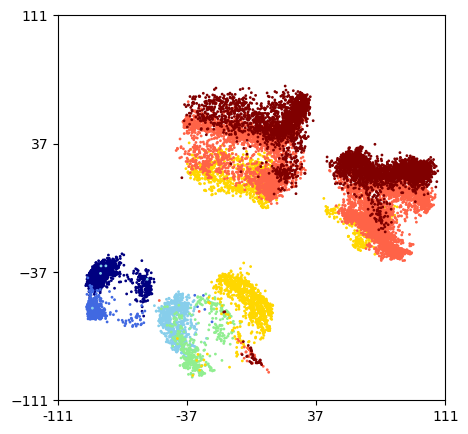

In [172]:
plt.figure(figsize = [5,5])
plt.scatter(ce_4_[:,0], ce_4_[:,1], c = labels, cmap = cmap, s = 1)

plt.xlim(-130,92)
plt.ylim(-111,111)
plt.xticks(np.linspace(-130,92,4), np.linspace(-111,111,4).astype(int))
plt.yticks(np.linspace(-111,111,4))

plt.savefig('../figures/brain/clusters4.png', format='png', dpi=300, bbox_inches='tight')

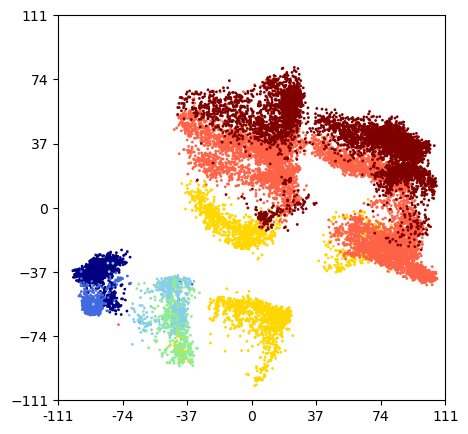

In [151]:
plt.figure(figsize = [5,5])
plt.scatter(ce_7_[:,0], ce_7_[:,1], c = labels, cmap = cmap, s = 1)

plt.xlim(-130,92)
plt.ylim(-111,111)
plt.xticks(np.linspace(-130,92,7), np.linspace(-111,111,7).astype(int))
plt.yticks(np.linspace(-111,111,7))

plt.savefig('../figures/brain/clusters7.png', format='png', dpi=300, bbox_inches='tight')

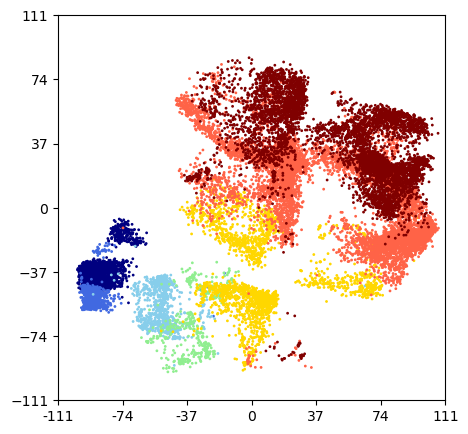

In [150]:
plt.figure(figsize = [5,5])
plt.scatter(ce_20_[:,0], ce_20_[:,1], c = labels, cmap = cmap, s = 1)

plt.xlim(-130,92)
plt.ylim(-111,111)
plt.xticks(np.linspace(-130,92,7), np.linspace(-111,111,7).astype(int))
plt.yticks(np.linspace(-111,111,7))

plt.savefig('../figures/brain/clusters20.png', format='png', dpi=300, bbox_inches='tight')

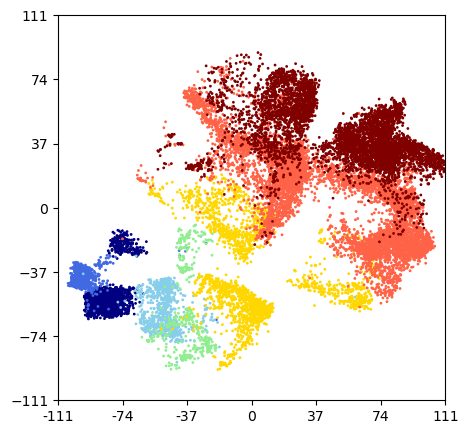

In [159]:
plt.figure(figsize = [5,5])
plt.scatter(ce_28_[:,0], ce_28_[:,1], c = labels, cmap = cmap, s = 1)

plt.xlim(-130,92)
plt.ylim(-111,111)
plt.xticks(np.linspace(-130,92,7), labels =np.linspace(-111,111,7).astype(int))
plt.yticks(np.linspace(-111,111,7))

plt.savefig('../figures/brain/clusters28.png', format='png', dpi=300, bbox_inches='tight')

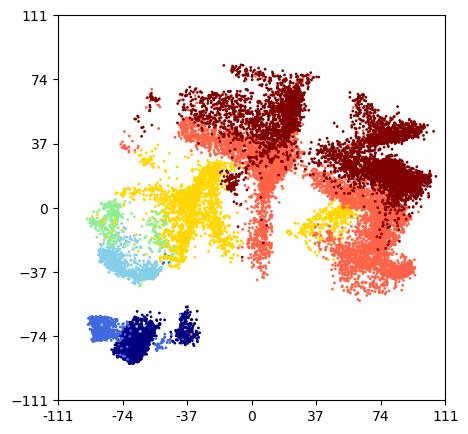

In [160]:
plt.figure(figsize = [5,5])
plt.scatter(ce_13[:,0], ce_13[:,1], c = labels, cmap = cmap, s = 1)

plt.xlim(-125,97)
plt.ylim(-111,111)
plt.xticks(np.linspace(-125,97,7), labels =np.linspace(-111,111,7).astype(int))
plt.yticks(np.linspace(-111,111,7))

plt.savefig('../figures/brain/clusters13.png', format='png', dpi=300, bbox_inches='tight')

In [175]:
with open('../results/brain/clustering_exps.pkl', 'wb') as file:  
    pickle.dump([ce_4_, ce_7_, ce_20_, ce_28_], file)

In [162]:
# metrics

geodesic_distances = pd.read_csv("C:/Users/codae/OneDrive/Documents/clustering_embedding_data/bio_geodesic_5.csv")
geodesic_distances = squareform(geodesic_distances.to_numpy().flatten())
geodesic_distances.shape

data = pd.read_csv("C:/Users/codae/OneDrive/Documents/clustering_embedding_data/bio_data_5k.csv")
idxs = data['idxs'].to_numpy()

In [163]:
all_embs = [ce_7, ce_13, ce_20, ce_28]

In [164]:
orig_distances = geodesic_distances
for emb in all_embs:
    emb_distances =  squareform(pdist(emb[idxs]))
    spearman_scores = spearman(orig_distances, emb_distances, labels[idxs])
    stress_scores = normalized_stress(orig_distances, emb_distances, labels[idxs])
    class_score = class_preservation(orig_distances, emb_distances, labels[idxs])
    scaled_stress_scores =  scale_normalized_stress(orig_distances, emb_distances, labels[idxs])
    recall_score = knn_recall(X[idxs], emb[idxs], [30])
    
    formatted = " & ".join(
    [
        f"${spearman_scores[0]:.2f}$",
        f"${stress_scores[0]:.2f}$",
        f"${scaled_stress_scores[0]:.2f}$",
        f"${recall_score[0]:.2f}$",
        *[f"${x:.2f}$" for x in spearman_scores[1:]],
        *[f"${x:.2f}$" for x in stress_scores[1:]],
        *[f"${x:.2f}$" for x in scaled_stress_scores[1:]],
        f"${class_score:.2f}$"
    ]
)


    print(formatted)
    print()

$0.78$ & $0.47$ & $0.39$ & $0.34$ & $0.62$ & $0.91$ & $0.24$ & $0.23$ & $0.20$ & $0.22$ & $0.97$

$0.80$ & $0.44$ & $0.38$ & $0.35$ & $0.68$ & $0.90$ & $0.23$ & $0.23$ & $0.20$ & $0.23$ & $0.93$

$0.81$ & $0.40$ & $0.33$ & $0.34$ & $0.60$ & $0.91$ & $0.24$ & $0.22$ & $0.21$ & $0.22$ & $0.93$

$0.81$ & $0.39$ & $0.32$ & $0.35$ & $0.61$ & $0.90$ & $0.24$ & $0.23$ & $0.20$ & $0.23$ & $0.93$

